I310D Final Project

Phyllis Stockton, Lauren Sadberry, Mariana Nino de Rivera

05/01/2025

To run this notebook, please visit the references section and click the CDC link, listed at the top of the list of the references section. Download the data as a CSV and adjust the file path argument when reading in the CSV to fit your machine.

In [51]:
# import libraries
from re import T
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [83]:
# read in the CSV
df = pd.read_csv('/content/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days_20250403.csv')

### Sanity Checks

In [3]:
df.head(5)

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
0,Symptoms of Depressive Disorder,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.5,22.7,24.3,22.7 - 24.3,NaN
1,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,32.7,30.2,35.2,30.2 - 35.2,NaN
2,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.7,24.1,27.3,24.1 - 27.3,NaN
3,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,24.8,23.3,26.2,23.3 - 26.2,NaN
4,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.2,21.5,25.0,21.5 - 25.0,NaN


In [4]:
df.tail(5)

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
16789,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Virginia,Virginia,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,20.8,17.4,24.5,17.4 - 24.5,19.5-21.5
16790,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Washington,Washington,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,19.9,17.4,22.6,17.4 - 22.6,19.5-21.5
16791,Symptoms of Anxiety Disorder or Depressive Dis...,By State,West Virginia,West Virginia,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,26.3,21.5,31.4,21.5 - 31.4,23.1-27.8
16792,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Wisconsin,Wisconsin,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,17.0,13.4,21.2,13.4 - 21.2,16.6-19.4
16793,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Wyoming,Wyoming,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,25.6,19.3,32.8,19.3 - 32.8,23.1-27.8


In [5]:
df.shape

(16794, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16794 entries, 0 to 16793
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Indicator               16794 non-null  object 
 1   Group                   16794 non-null  object 
 2   State                   16794 non-null  object 
 3   Subgroup                16794 non-null  object 
 4   Phase                   16794 non-null  object 
 5   Time Period             16794 non-null  int64  
 6   Time Period Label       16794 non-null  object 
 7   Time Period Start Date  16794 non-null  object 
 8   Time Period End Date    16794 non-null  object 
 9   Value                   16087 non-null  float64
 10  Low CI                  16087 non-null  float64
 11  High CI                 16087 non-null  float64
 12  Confidence Interval     16087 non-null  object 
 13  Quartile Range          11017 non-null  object 
dtypes: float64(3), int64(1), object(10)
me

In [7]:
df.describe()

,Time Period,Value,Low CI,High CI
count,16794.000000,16087.000000,16087.000000,16087.000000
mean,35.922830,28.140946,24.642270,31.893181
std,21.530312,8.951691,8.593666,9.481899
min,1.000000,4.600000,3.300000,6.000000
25%,17.000000,22.100000,18.700000,25.500000
50%,37.000000,27.700000,24.100000,31.600000
75%,55.000000,33.400000,29.700000,37.400000
max,72.000000,85.200000,79.900000,89.500000


### Data Wrangling

In [84]:
# find missing values
missing = df.isnull().sum()
print(missing)

Indicator                    0
Group                        0
State                        0
Subgroup                     0
Phase                        0
Time Period                  0
Time Period Label            0
Time Period Start Date       0
Time Period End Date         0
Value                      707
Low CI                     707
High CI                    707
Confidence Interval        707
Quartile Range            5777
dtype: int64


In [85]:
# Drop unwanted columns
df = df.drop('State', axis=1)
df = df.drop('Quartile Range', axis=1)
df = df.drop('Confidence Interval', axis=1)
df = df.drop('Low CI', axis=1)
df = df.drop('High CI', axis=1)
df = df.drop('Phase', axis=1)
df = df.drop('Time Period', axis=1)
df = df.drop('Time Period Label', axis=1)

In [86]:
# drop NaN
df = df.dropna()

# check missing values
missing = df.isnull().sum()
print(missing)

Indicator                 0
Group                     0
Subgroup                  0
Time Period Start Date    0
Time Period End Date      0
Value                     0
dtype: int64


In [87]:
# standardize case
df['Subgroup'] = df['Subgroup'].str.lower()
df['Group'] = df['Group'].str.lower()
df

,Indicator,Group,Subgroup,Time Period Start Date,Time Period End Date,Value
0,Symptoms of Depressive Disorder,national estimate,united states,04/23/2020,05/05/2020,23.5
1,Symptoms of Depressive Disorder,by age,18 - 29 years,04/23/2020,05/05/2020,32.7
2,Symptoms of Depressive Disorder,by age,30 - 39 years,04/23/2020,05/05/2020,25.7
3,Symptoms of Depressive Disorder,by age,40 - 49 years,04/23/2020,05/05/2020,24.8
4,Symptoms of Depressive Disorder,by age,50 - 59 years,04/23/2020,05/05/2020,23.2
...,...,...,...,...,...,...
16789,Symptoms of Anxiety Disorder or Depressive Dis...,by state,virginia,08/20/2024,09/16/2024,20.8
16790,Symptoms of Anxiety Disorder or Depressive Dis...,by state,washington,08/20/2024,09/16/2024,19.9
16791,Symptoms of Anxiety Disorder or Depressive Dis...,by state,west virginia,08/20/2024,09/16/2024,26.3
16792,Symptoms of Anxiety Disorder or Depressive Dis...,by state,wisconsin,08/20/2024,09/16/2024,17.0


In [88]:
# Update data types
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'])
df['Time Period End Date'] = pd.to_datetime(df['Time Period End Date'])

# update Value column to convert to float
df['Value'] = df['Value'].astype(float)
df

,Indicator,Group,Subgroup,Time Period Start Date,Time Period End Date,Value
0,Symptoms of Depressive Disorder,national estimate,united states,2020-04-23,2020-05-05,23.5
1,Symptoms of Depressive Disorder,by age,18 - 29 years,2020-04-23,2020-05-05,32.7
2,Symptoms of Depressive Disorder,by age,30 - 39 years,2020-04-23,2020-05-05,25.7
3,Symptoms of Depressive Disorder,by age,40 - 49 years,2020-04-23,2020-05-05,24.8
4,Symptoms of Depressive Disorder,by age,50 - 59 years,2020-04-23,2020-05-05,23.2
...,...,...,...,...,...,...
16789,Symptoms of Anxiety Disorder or Depressive Dis...,by state,virginia,2024-08-20,2024-09-16,20.8
16790,Symptoms of Anxiety Disorder or Depressive Dis...,by state,washington,2024-08-20,2024-09-16,19.9
16791,Symptoms of Anxiety Disorder or Depressive Dis...,by state,west virginia,2024-08-20,2024-09-16,26.3
16792,Symptoms of Anxiety Disorder or Depressive Dis...,by state,wisconsin,2024-08-20,2024-09-16,17.0


In [89]:
# rename values in indicator column
vals = df['Indicator'].unique()
changes = {'Symptoms of Depressive Disorder' : 'depression',
           'Symptoms of Anxiety Disorder' : 'anxiety',
           'Symptoms of Anxiety Disorder or Depressive Disorder' : 'depression or anxiety'}
df['Symptoms'] = df['Indicator'].map(changes)
df = df.drop('Indicator', axis=1)
df.head()

,Group,Subgroup,Time Period Start Date,Time Period End Date,Value,Symptoms
0,national estimate,united states,2020-04-23,2020-05-05,23.5,depression
1,by age,18 - 29 years,2020-04-23,2020-05-05,32.7,depression
2,by age,30 - 39 years,2020-04-23,2020-05-05,25.7,depression
3,by age,40 - 49 years,2020-04-23,2020-05-05,24.8,depression
4,by age,50 - 59 years,2020-04-23,2020-05-05,23.2,depression


In [90]:
# reset index
df.reset_index(drop=True, inplace=True)

In [91]:
df.shape

(16087, 6)

### Gender LM - Mariana

In [43]:
# set start date to index
df = df.reset_index()
df.head()

,Time Period Start Date,Group,Subgroup,Time Period End Date,Value,Symptoms
0,2020-04-23,national estimate,united states,2020-05-05,23.5,depression
1,2020-04-23,by age,18 - 29 years,2020-05-05,32.7,depression
2,2020-04-23,by age,30 - 39 years,2020-05-05,25.7,depression
3,2020-04-23,by age,40 - 49 years,2020-05-05,24.8,depression
4,2020-04-23,by age,50 - 59 years,2020-05-05,23.2,depression


In [92]:
# isolate gender group
gender_df = df[df["Group"] == "by sex"]
gender_df.head()

,Group,Subgroup,Time Period Start Date,Time Period End Date,Value,Symptoms
8,by sex,male,2020-04-23,2020-05-05,20.8,depression
9,by sex,female,2020-04-23,2020-05-05,26.1,depression
78,by sex,male,2020-04-23,2020-05-05,26.1,anxiety
79,by sex,female,2020-04-23,2020-05-05,35.4,anxiety
148,by sex,male,2020-04-23,2020-05-05,31.0,depression or anxiety


Text(0.5, 1.0, 'Frequency of Mental Illness Among Females and Males')

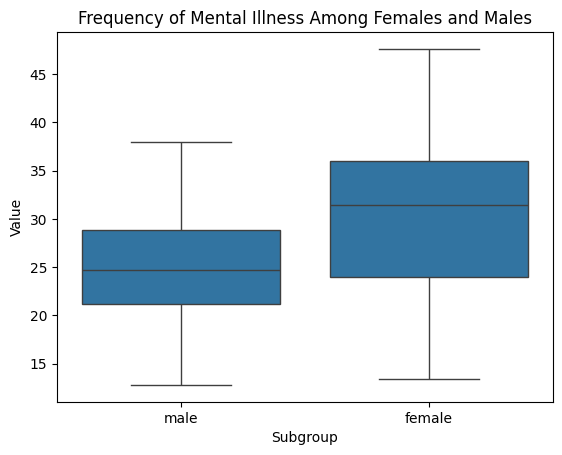

In [93]:
# make box plots of categorical values
box = sns.boxplot(x = 'Subgroup', y = 'Value', data=gender_df)
plt.title('Frequency of Mental Illness Among Females and Males')

In [94]:
# group by gender
group_by_gender = gender_df[['Time Period Start Date', 'Subgroup', 'Value']].groupby(['Subgroup'])
male_group = group_by_gender.get_group('male').groupby('Time Period Start Date')['Value'].mean()
female_group = group_by_gender.get_group('female').groupby('Time Period Start Date')['Value'].mean()

<ipython-input-94-785831183834>:3: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  male_group = group_by_gender.get_group('male').groupby('Time Period Start Date')['Value'].mean()
<ipython-input-94-785831183834>:4: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  female_group = group_by_gender.get_group('female').groupby('Time Period Start Date')['Value'].mean()


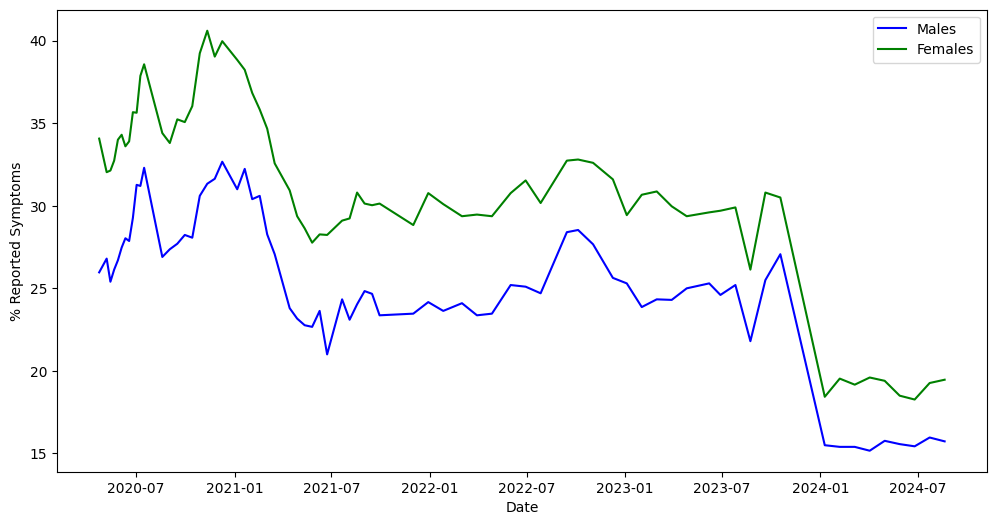

In [95]:
# plot line graph showing male and female mental illness trend over time
plt.figure(figsize=(12, 6))
plt.plot(male_group.index, male_group, color = "blue", label = "Males")
plt.plot(female_group.index, female_group, color = "green", label = "Females")
plt.xlabel("Date")
plt.ylabel("% Reported Symptoms")
plt.legend()

In [99]:
print(male_group.columns)

Index(['Time Period Start Date', 'Value', 'Date_ordinal'], dtype='object')


In [100]:
# Reset and rename for males
male_group.columns = ['Time Period Start Date', 'Value', 'Date_ordinal']  # explicitly name columns
male_group['Date_ordinal'] = male_group['Time Period Start Date'].map(pd.Timestamp.toordinal)

X_male = male_group[['Date_ordinal']]
y_male = male_group['Value']

lm_male = LinearRegression()
lm_male.fit(X_male, y_male)

print("Male Coefficients:", lm_male.coef_)
print("Male Intercept:", lm_male.intercept_)
y_pred_male = lm_male.predict(X_male)
print("Male R^2 Score:", r2_score(y_male, y_pred_male))

# Reset and rename for females
female_group = female_group.reset_index()
female_group.columns = ['Time Period Start Date', 'Value']
female_group['Date_ordinal'] = female_group['Time Period Start Date'].map(pd.Timestamp.toordinal)

X_female = female_group[['Date_ordinal']]
y_female = female_group['Value']

lm_female = LinearRegression()
lm_female.fit(X_female, y_female)

print("Female Coefficients:", lm_female.coef_)
print("Female Intercept:", lm_female.intercept_)
y_pred_female = lm_female.predict(X_female)
print("Female R^2 Score:", r2_score(y_female, y_pred_female))

Male Coefficients: [-0.0068716]
Male Intercept: 5097.387880502367
Male R^2 Score: 0.5428891715603492
Female Coefficients: [-0.00901753]
Female Intercept: 6687.159397376946
Female R^2 Score: 0.6352342561859592


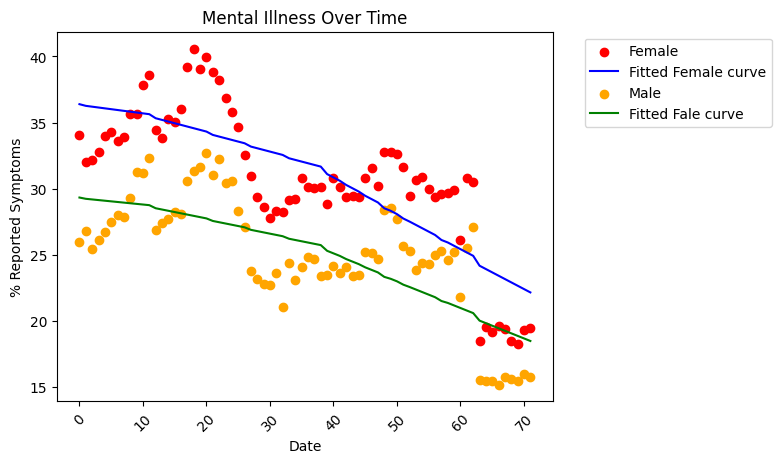

In [101]:
# plot original data against linear regression curve
plt.scatter(female_group.index, y_female, color='red', label='Female')
plt.plot(female_group.index, y_pred_female, color='blue', label='Fitted Female curve')
plt.scatter(male_group.index, y_male, color='orange', label='Male')
plt.plot(male_group.index, y_pred_male, color='green', label='Fitted Fale curve')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("% Reported Symptoms")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Mental Illness Over Time")
plt.show()

Polynomial coefficients: [-1.38420393e-08  3.06526226e-02 -2.26263238e+04  5.56722993e+09]
R² score: 0.7208159853337512


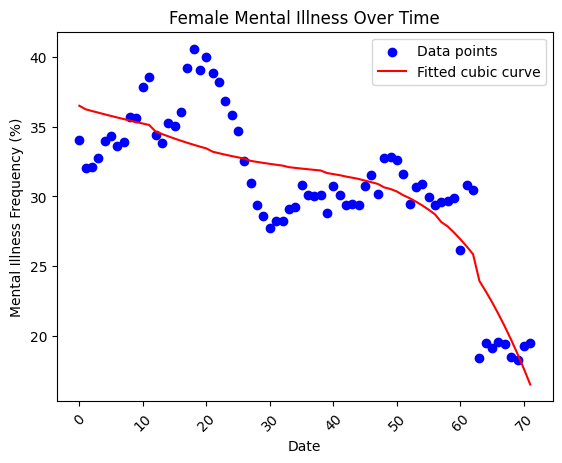

In [102]:
X = female_group['Date_ordinal']
y_female = female_group['Value']

# Step 1: Fit a polynomial (degree 3) to the data
coeffs = np.polyfit(X, y_female, deg=3)

# Coefficients of quadratic fit
print("Polynomial coefficients:", coeffs)

# Generate the fitted quadratic curve
y_pred_female = np.polyval(coeffs, X)

r2 = r2_score(y_female, y_pred_female)
print(f"R² score: {r2}")

# Plot original data and fitted quadratic curve
plt.scatter(female_group.index, y_female, color='blue', label='Data points')
plt.plot(female_group.index, y_pred_female, color='red', label='Fitted cubic curve')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Mental Illness Frequency (%)")
plt.title("Female Mental Illness Over Time")
plt.legend()
plt.show()

Polynomial coefficients: [-1.36725720e-08  3.02782851e-02 -2.23506980e+04  5.49958186e+09]
R² score: 0.6469923333939591



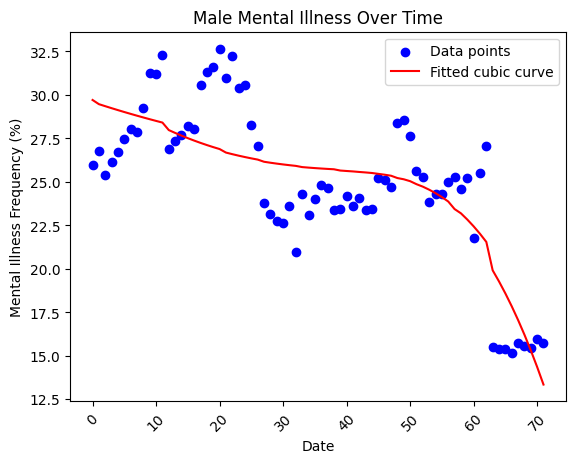

In [103]:
X = male_group['Date_ordinal']
y_male = male_group['Value']

# Step 1: Fit a polynomial (degree 3) to the data
coeffs = np.polyfit(X, y_male, deg=3)

# Coefficients of quadratic fit
print("Polynomial coefficients:", coeffs)

# Generate the fitted quadratic curve
y_pred_male = np.polyval(coeffs, X)

r2 = r2_score(y_male, y_pred_male)
print(f"R² score: {r2}")
print()

# Plot original data and fitted quadratic curve
plt.scatter(male_group.index, y_male, color='blue', label='Data points')
plt.plot(male_group.index, y_pred_male, color='red', label='Fitted cubic curve')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Mental Illness Frequency (%)")
plt.title("Male Mental Illness Over Time")
plt.legend()
plt.show()

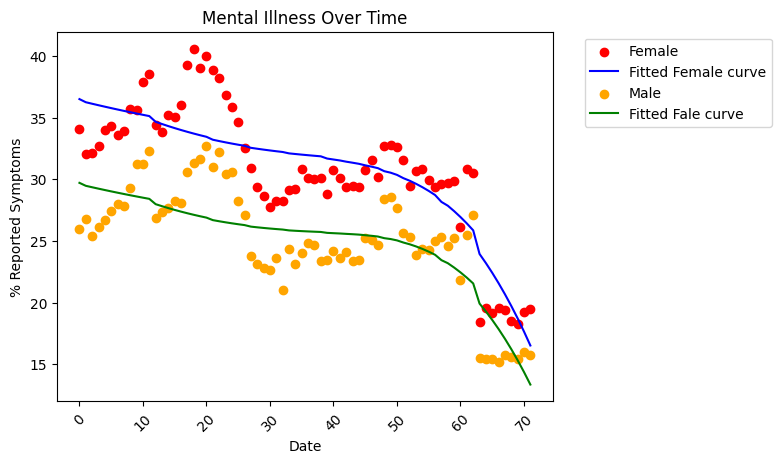

In [104]:
# Plot original data and fitted quadratic curve
plt.scatter(female_group.index, y_female, color='red', label='Female')
plt.plot(female_group.index, y_pred_female, color='blue', label='Fitted Female curve')
plt.scatter(male_group.index, y_male, color='orange', label='Male')
plt.plot(male_group.index, y_pred_male, color='green', label='Fitted Fale curve')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("% Reported Symptoms")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Mental Illness Over Time")
plt.show()

In [105]:
# One-hot encoding
gender_dummies = pd.get_dummies(gender_df, columns=['Subgroup'], prefix='gender', drop_first = True)
gender_dummies

,Group,Time Period Start Date,Time Period End Date,Value,Symptoms,gender_male
8,by sex,2020-04-23,2020-05-05,20.8,depression,True
9,by sex,2020-04-23,2020-05-05,26.1,depression,False
78,by sex,2020-04-23,2020-05-05,26.1,anxiety,True
79,by sex,2020-04-23,2020-05-05,35.4,anxiety,False
148,by sex,2020-04-23,2020-05-05,31.0,depression or anxiety,True
...,...,...,...,...,...,...
15862,by sex,2024-08-20,2024-09-16,14.4,depression,False
15939,by sex,2024-08-20,2024-09-16,15.0,anxiety,True
15940,by sex,2024-08-20,2024-09-16,20.2,anxiety,False
16017,by sex,2024-08-20,2024-09-16,18.9,depression or anxiety,True


MSE: 48.9573
MAE: 5.7593
MPE: -9.07%
R-squared: 0.04422035402198199
Coefficients: [-6.16455206]
Intercept: 31.060335195530726


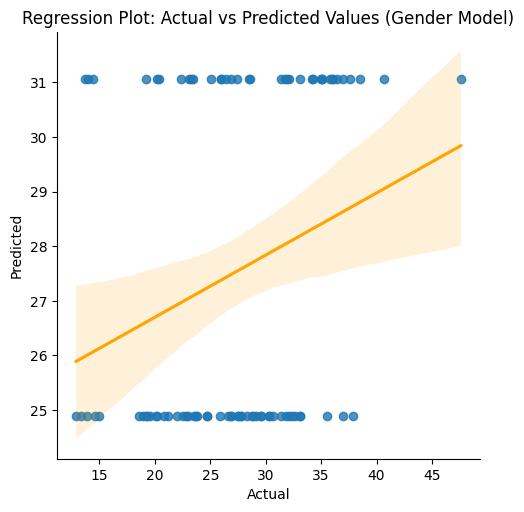

In [106]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# create the linear regression object
lm_gender = LinearRegression()

# set up input parameters for Linear Regression Model
X = gender_dummies[['gender_male']]
Y = gender_df['Value']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
    )

# fit the linear model
lm_gender.fit(X_train, Y_train)

# Existing
Y_pred = lm_gender.predict(X_test)

# Metrics
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
mpe = np.mean((Y_test - Y_pred) / Y_test) * 100  # Mean Percentage Error

# Print results
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MPE: {mpe:.2f}%")
print("R-squared:", r2_score(Y_test, Y_pred))
print("Coefficients:", lm_gender.coef_)
print("Intercept:", lm_gender.intercept_)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred
})

# Plot regression
sns.lmplot(x='Actual', y='Predicted', data=results_df, line_kws={'color': 'orange'})
plt.title('Regression Plot: Actual vs Predicted Values (Gender Model)')
plt.show()

### Age LM - Phyllis

In [ ]:
# reset index
df = df.reset_index()

In [ ]:
# isolate age group
age_df = df[df["Group"] == "by age"]
age_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 1 to 16016
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   index                   1512 non-null   int64         
 1   Group                   1512 non-null   object        
 2   Subgroup                1512 non-null   object        
 3   Time Period Start Date  1512 non-null   datetime64[ns]
 4   Time Period End Date    1512 non-null   datetime64[ns]
 5   Value                   1512 non-null   float64       
 6   Symptoms                1512 non-null   object        
 7   Age Mid                 1512 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 106.3+ KB


In [ ]:
age_df.describe()

,index,Time Period Start Date,Time Period End Date,Value,Age Mid
count,1512.000000,1512,1512,1512.000000,1512.000000
mean,7800.907407,2022-01-05 04:00:00.000000256,2022-01-17 22:39:59.999999744,25.895172,54.428571
min,1.000000,2020-04-23 00:00:00,2020-05-05 00:00:00,4.600000,23.500000
25%,3765.000000,2020-11-07 12:00:00,2020-11-19 12:00:00,16.800000,34.500000
50%,7633.000000,2021-08-25 00:00:00,2021-09-06 00:00:00,24.800000,54.500000
75%,11827.000000,2023-02-08 00:00:00,2023-02-20 00:00:00,34.700000,74.500000
max,16016.000000,2024-08-20 00:00:00,2024-09-16 00:00:00,58.700000,85.000000
std,4661.199270,NaN,NaN,11.211535,20.329879


[Text(0.5, 0, 'Symptom %')]

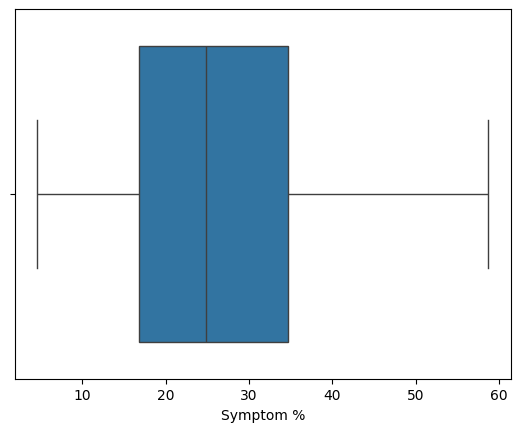

In [ ]:
# symptom box plot
plot = sns.boxplot(x=age_df["Value"])
plot.set(xlabel='Symptom %')

In [ ]:
# get age groups
age = age_df[['Subgroup', 'Value']].groupby(['Subgroup'])
ages = age_df['Subgroup'].unique()
print(ages)

['18 - 29 years' '30 - 39 years' '40 - 49 years' '50 - 59 years'
 '60 - 69 years' '70 - 79 years' '80 years and above']


In [ ]:
# One-hot encoding
age_dummies = pd.get_dummies(age_df, columns=['Subgroup'], prefix='age', drop_first=True)
age_dummies

,index,Group,Time Period Start Date,Time Period End Date,Value,Symptoms,age_30 - 39 years,age_40 - 49 years,age_50 - 59 years,age_60 - 69 years,age_70 - 79 years,age_80 years and above
1,1,by age,2020-04-23,2020-05-05,32.7,depression,False,False,False,False,False,False
2,2,by age,2020-04-23,2020-05-05,25.7,depression,True,False,False,False,False,False
3,3,by age,2020-04-23,2020-05-05,24.8,depression,False,True,False,False,False,False
4,4,by age,2020-04-23,2020-05-05,23.2,depression,False,False,True,False,False,False
5,5,by age,2020-04-23,2020-05-05,18.4,depression,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
16012,16012,by age,2024-08-20,2024-09-16,21.0,depression or anxiety,False,True,False,False,False,False
16013,16013,by age,2024-08-20,2024-09-16,20.3,depression or anxiety,False,False,True,False,False,False
16014,16014,by age,2024-08-20,2024-09-16,14.0,depression or anxiety,False,False,False,True,False,False
16015,16015,by age,2024-08-20,2024-09-16,9.5,depression or anxiety,False,False,False,False,True,False


In [ ]:
# make list of age subgroups excluding reference group
ages = [
        'age_30 - 39 years',
	              'age_40 - 49 years',
                'age_50 - 59 years',
                'age_60 - 69 years',
                'age_70 - 79 years',
                'age_80 years and above']

In [ ]:
# input parameters
X = age_dummies[ages]
Y = age_df['Value']

# 80-20 training-test data split
X_train, X_test, Y_train, Y_test = train_test_split (
    X, Y, test_size=0.2, random_state=42
    )

# fit the linear model
lm_age = LinearRegression()
lm_age = lm_age.fit(X_train, Y_train)

# get predicted values
Y_pred = lm_age.predict(X_test)

# mean percent error
mpe = np.mean((Y_test - Y_pred) / Y_test) * 100

print("MSE:", mean_squared_error(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("MPE:", mpe)
print("R-squared:", r2)
print("Coefficients:", lm_age.coef_)
print("Intercept:", lm_age.intercept_)

MSE: 41.19442826495814
MAE: 5.194069627382077
MPE: -5.635151504990692
R-squared: 0.672778714036592
Coefficients: [ -7.95065719 -11.62959065 -15.15296933 -20.53441567 -26.51138313
 -27.12479095]
Intercept: 41.37898089171971


In [ ]:
# age grouped rates over time
age_df.head(5)

,index,Group,Subgroup,Time Period Start Date,Time Period End Date,Value,Symptoms
1,1,by age,18 - 29 years,2020-04-23,2020-05-05,32.7,depression
2,2,by age,30 - 39 years,2020-04-23,2020-05-05,25.7,depression
3,3,by age,40 - 49 years,2020-04-23,2020-05-05,24.8,depression
4,4,by age,50 - 59 years,2020-04-23,2020-05-05,23.2,depression
5,5,by age,60 - 69 years,2020-04-23,2020-05-05,18.4,depression


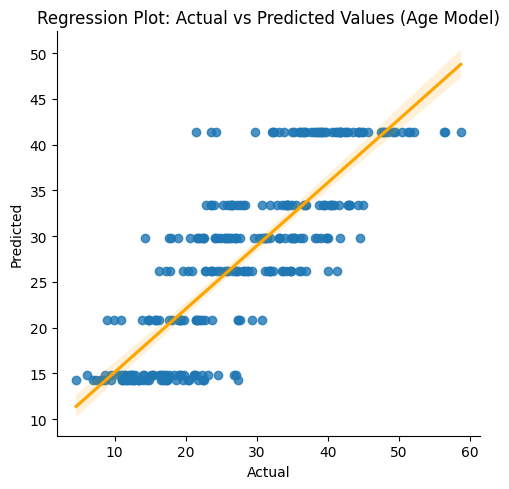

In [ ]:
# data frame for easier plotting
results_df = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred
})

# create linear model plot
sns.lmplot(x = 'Actual', y = 'Predicted', data=results_df, line_kws = {'color': 'orange'})
plt.title('Regression Plot: Actual vs Predicted Values (Age Model)')
plt.tight_layout()
plt.show()

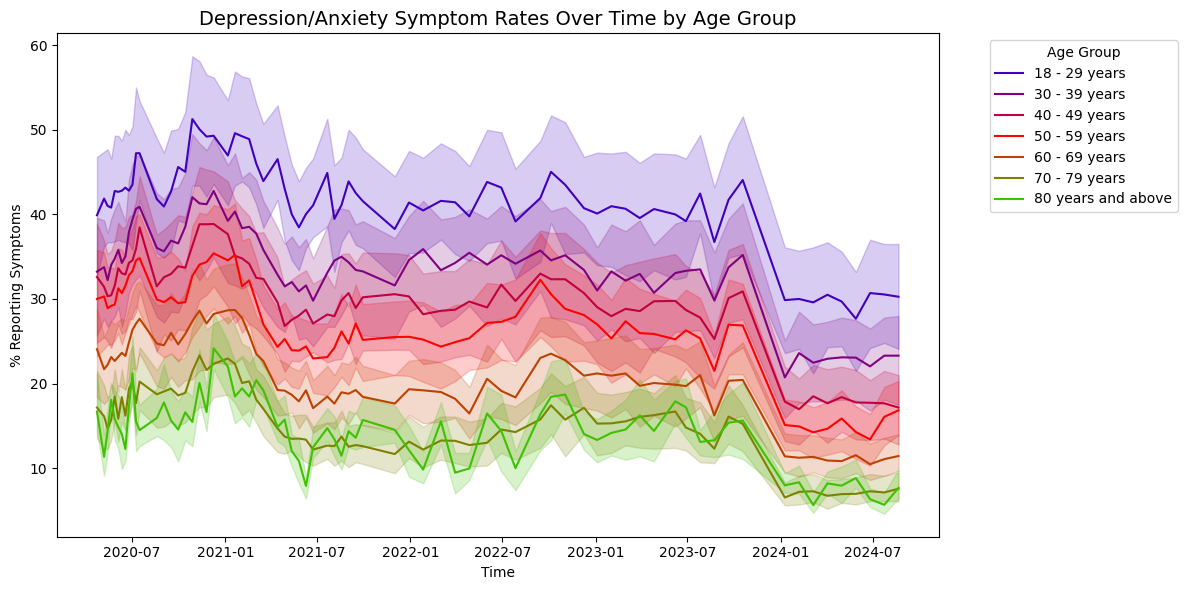

In [ ]:
# create the lineplot
plt.figure(figsize = (12, 6))
sns.lineplot(
    data = age_df,
    x = 'Time Period Start Date',
    y = 'Value',
    hue = 'Subgroup',
    palette = 'brg',
)

# update layout
plt.title('Depression/Anxiety Symptom Rates Over Time by Age Group', fontsize = 14)
plt.xlabel('Time')
plt.ylabel('% Reporting Symptoms')
plt.legend(title = 'Age Group', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

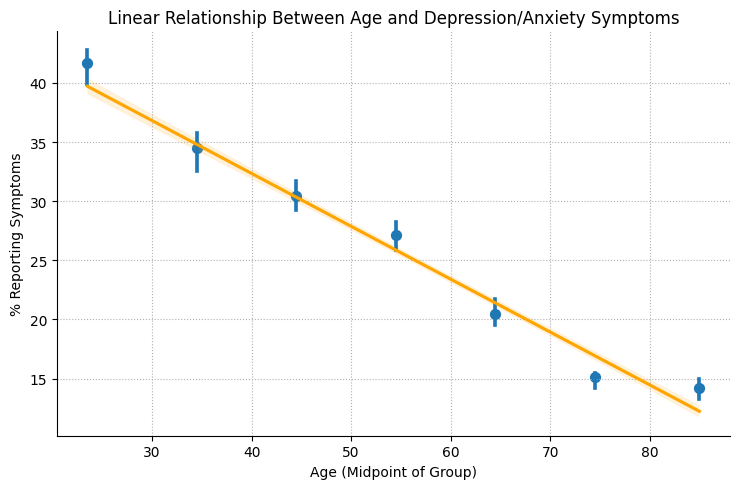

In [ ]:
# create midpoints for readability
age_mid = {
    '18 - 29 years': 23.5,
    '30 - 39 years': 34.5,
    '40 - 49 years': 44.5,
    '50 - 59 years': 54.5,
    '60 - 69 years': 64.5,
    '70 - 79 years': 74.5,
    '80 years and above': 85
}

# add to age_df
df['Age Mid'] = df['Subgroup'].map(age_mid)

# create the linear model plot
viz3 = sns.lmplot(
    data = age_df,
    x = 'Age Mid',
    y = 'Value',
    aspect = 1.5,
    line_kws = {'color': 'orange'},
    x_estimator = np.median
)

# add grid
for ax in viz3.axes.flat:
    ax.grid(True, axis = 'both', linestyle=':')

# update layout
plt.title('Linear Relationship Between Age and Depression/Anxiety Symptoms')
plt.xlabel('Age (Midpoint of Group)')
plt.ylabel('% Reporting Symptoms')
plt.tight_layout()
plt.show()

### Race LM - Lauren

In [ ]:
df = df.reset_index()

In [ ]:
race_df = df[df["Group"] == "By Race/Hispanic ethnicity"]
race_df

,index,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
10,10,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,Hispanic or Latino,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,29.4,26.8,32.1,26.8 - 32.1,NaN
11,11,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic White, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,21.4,20.6,22.1,20.6 - 22.1,NaN
12,12,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic Black, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.6,23.7,27.5,23.7 - 27.5,NaN
13,13,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic Asian, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.6,20.3,27.1,20.3 - 27.1,NaN
14,14,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic, other races and multiple races",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,28.3,24.8,32.0,24.8 - 32.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,16732,Symptoms of Anxiety Disorder or Depressive Dis...,By Race/Hispanic ethnicity,United States,Hispanic or Latino,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,24.1,21.9,26.4,21.9 - 26.4,NaN
16733,16733,Symptoms of Anxiety Disorder or Depressive Dis...,By Race/Hispanic ethnicity,United States,"Non-Hispanic White, single race",4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,21.3,20.5,22.1,20.5 - 22.1,NaN
16734,16734,Symptoms of Anxiety Disorder or Depressive Dis...,By Race/Hispanic ethnicity,United States,"Non-Hispanic Black, single race",4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,19.6,17.4,22.0,17.4 - 22.0,NaN
16735,16735,Symptoms of Anxiety Disorder or Depressive Dis...,By Race/Hispanic ethnicity,United States,"Non-Hispanic Asian, single race",4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,12.6,10.2,15.2,10.2 - 15.2,NaN


In [ ]:
race_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1230 entries, 10 to 16736
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   1230 non-null   int64  
 1   Indicator               1230 non-null   object 
 2   Group                   1230 non-null   object 
 3   State                   1230 non-null   object 
 4   Subgroup                1230 non-null   object 
 5   Phase                   1230 non-null   object 
 6   Time Period             1230 non-null   int64  
 7   Time Period Label       1230 non-null   object 
 8   Time Period Start Date  1230 non-null   object 
 9   Time Period End Date    1230 non-null   object 
 10  Value                   1080 non-null   float64
 11  Low CI                  1080 non-null   float64
 12  High CI                 1080 non-null   float64
 13  Confidence Interval     1080 non-null   object 
 14  Quartile Range          0 non-null      obj

In [ ]:
race_df.describe()

,index,Time Period,Value,Low CI,High CI
count,1230.000000,1230.000000,1080.000000,1080.000000,1080.000000
mean,8184.390244,32.170732,29.196759,26.809815,31.687222
std,4767.593812,22.684989,8.597849,8.239046,9.021480
min,10.000000,1.000000,8.800000,6.900000,11.000000
25%,4129.250000,11.000000,23.000000,20.800000,25.100000
50%,8115.000000,31.500000,29.350000,27.100000,31.750000
75%,12128.750000,52.000000,35.100000,32.525000,37.700000
max,16736.000000,72.000000,52.600000,48.400000,56.800000


In [ ]:
race = race_df[['Subgroup', 'Value']].groupby(['Subgroup'])
races = race_df['Subgroup'].unique()

# select specific group from grouped data
hispanic_or_latino = race.get_group('Hispanic or Latino')['Value']
white = race.get_group('Non-Hispanic White, single race')['Value']
black = race.get_group('Non-Hispanic Black, single race')['Value']
asian = race.get_group('Non-Hispanic Asian, single race')['Value']
other_mixed = race.get_group('Non-Hispanic, other races and multiple races')['Value']


<ipython-input-14-560dbb282cae>:5: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  hispanic_or_latino = race.get_group('Hispanic or Latino')['Value']
<ipython-input-14-560dbb282cae>:6: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  white = race.get_group('Non-Hispanic White, single race')['Value']
<ipython-input-14-560dbb282cae>:7: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  black = race.get_group('Non-Hispanic Black, single race')['Value']
<ipython-input-14-560dbb282cae>:8: FutureWarning: When grouping with a length-1 list-like, you wi

In [ ]:
# Drop rows where 'Value' is NaN
race_df_clean = race_df.dropna(subset=['Value'])

# Regenerate dummy variables from the cleaned DataFrame
race_dummies = pd.get_dummies(race_df_clean['Subgroup'])

# Define race groups again if needed
races = [
    'Hispanic or Latino',
    'Non-Hispanic White, single race',
    'Non-Hispanic Black, single race',
    'Non-Hispanic Asian, single race',
    'Non-Hispanic, other races and multiple races'
]

# Prepare input features and target variable
X = race_dummies[races]
Y = race_df_clean['Value']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Create and fit linear regression model
lm_race = LinearRegression()
lm_race.fit(X_train, Y_train)

# Make predictions
Y_pred = lm_race.predict(X_test)

# Evaluation metrics
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
mpe = np.mean((Y_test - Y_pred) / Y_test) * 100

# Print results
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MPE: {mpe:.2f}%")
print("R-squared:", r2)
print("Coefficients:", lm_race.coef_)
print("Intercept:", lm_race.intercept_)


MSE: 50.0748
MAE: 5.6714
MPE: -9.62%
R-squared: 0.25682950210629696
Coefficients: [ 2.38933899 -2.47405005 -0.14788394 -7.65245881  7.88505382]
Intercept: 29.344531981938758


The regression results show that race has a modest impact on predicting the outcome, with an R-squared of 0.26, meaning the model explains about 26% of the variance. The MSE (50.07) and MAE (5.67) indicate average prediction errors of around 7 and 5.7 units, respectively. The model tends to underpredict values by about 9.6% on average. Coefficients suggest that being Hispanic (+2.39) or of other/mixed race (+7.89) slightly increases the predicted value, while being Asian (−7.65) or White (−2.47) decreases it. Overall, race contributes to the prediction, but not strongly—other factors likely play a larger role

In [ ]:
race_df = race_df.reset_index()
race_df.head(5)

,level_0,index,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
0,10,10,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,Hispanic or Latino,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,29.4,26.8,32.1,26.8 - 32.1,NaN
1,11,11,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic White, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,21.4,20.6,22.1,20.6 - 22.1,NaN
2,12,12,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic Black, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.6,23.7,27.5,23.7 - 27.5,NaN
3,13,13,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic Asian, single race",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.6,20.3,27.1,20.3 - 27.1,NaN
4,14,14,Symptoms of Depressive Disorder,By Race/Hispanic ethnicity,United States,"Non-Hispanic, other races and multiple races",1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,28.3,24.8,32.0,24.8 - 32.0,NaN


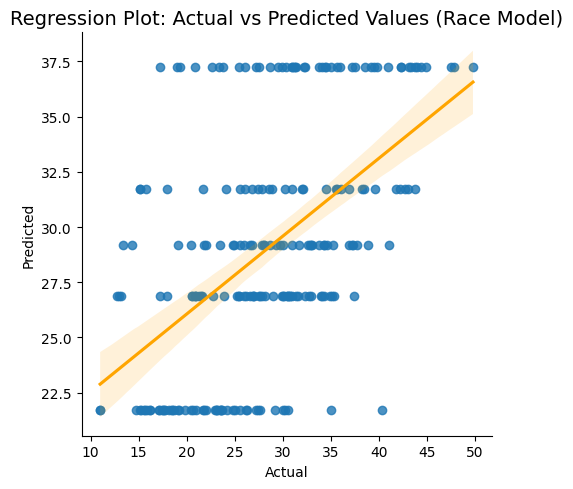

In [ ]:
# Re-split and fit the race model
X = race_dummies[races]
Y = race_df_clean['Value']  # use cleaned data without NaNs
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

lm_race = LinearRegression()
lm_race.fit(X_train, Y_train)
Y_pred = lm_race.predict(X_test)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred
})

# Plot regression
sns.lmplot(x='Actual', y='Predicted', data=results_df, line_kws={'color': 'orange'})
plt.title('Regression Plot: Actual vs Predicted Values (Race Model)', fontsize=14)
plt.tight_layout()
plt.show()


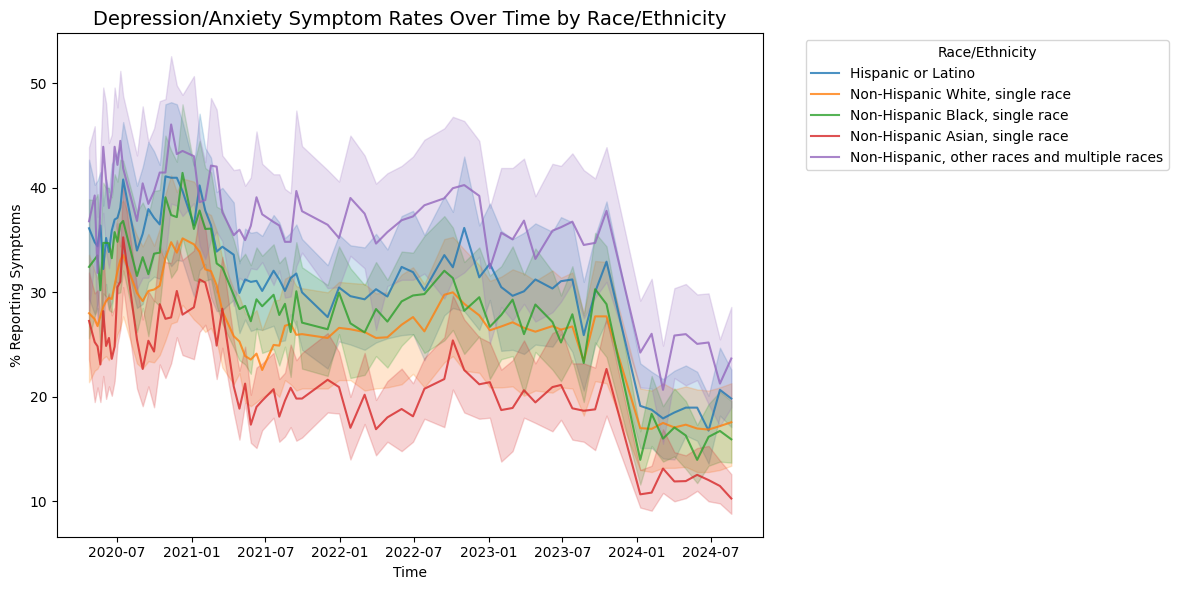

In [ ]:
# Convert date column to datetime
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'])

# Filter for race/ethnicity group data
race_df = df[df['Group'] == 'By Race/Hispanic ethnicity'].copy()

# Drop missing subgroup/value rows (just in case)
race_df = race_df.dropna(subset=['Subgroup', 'Value'])

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=race_df,
    x='Time Period Start Date',
    y='Value',
    hue='Subgroup',
    alpha=0.8
)

plt.title('Depression/Anxiety Symptom Rates Over Time by Race/Ethnicity', fontsize=14)
plt.xlabel('Time')
plt.ylabel('% Reporting Symptoms')
plt.legend(title='Race/Ethnicity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



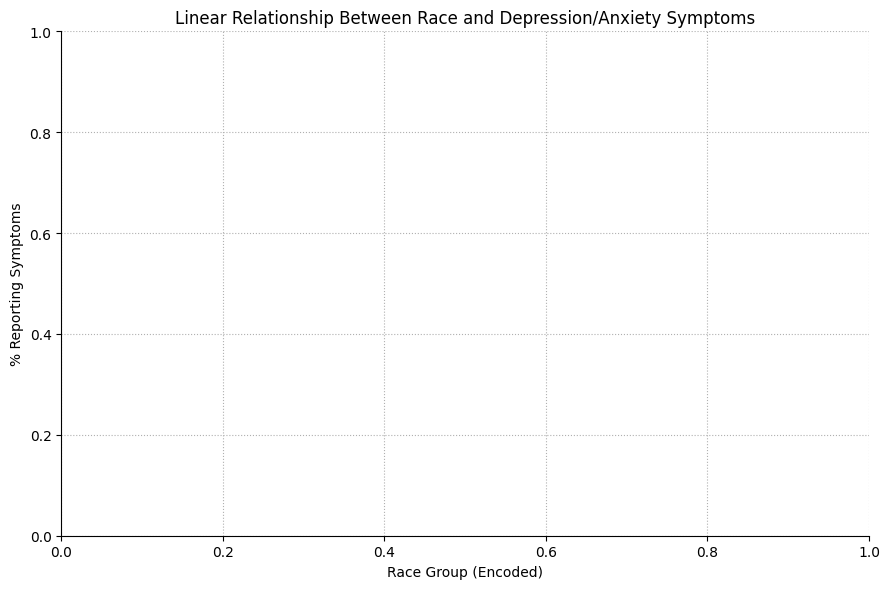

In [ ]:
# Map race/ethnicity labels to numeric codes for plotting
race_numeric_map = {
    'Hispanic or Latino': 1,
    'Non-Hispanic White, single race': 2,
    'Non-Hispanic Black, single race': 3,
    'Non-Hispanic Asian, single race': 4,
    'Non-Hispanic, other races and multiple races': 5
}

# Add numeric code column
df['Race Code'] = df['Subgroup'].map(race_numeric_map)

# Filter for race/ethnicity group data
race_df = df[df['Group'] == 'By Race/Hispanic ethnicity'].copy()
race_df = race_df.dropna(subset=['Value', 'Subgroup'])  # Clean nulls

# Map race codes again just for safety (in case you filtered after assigning)
race_df['Race Code'] = race_df['Subgroup'].map(race_numeric_map)

# Create the lmplot
viz3 = sns.lmplot(
    data=race_df,
    x='Race Code',
    y='Value',
    height=6,
    aspect=1.5,
    line_kws={'color': 'orange'},
    x_estimator=np.median
)

# Customize grid and labels
for ax in viz3.axes.flat:
    ax.grid(True, axis='both', linestyle=':')

plt.title('Linear Relationship Between Race and Depression/Anxiety Symptoms')
plt.xlabel('Race Group (Encoded)')
plt.ylabel('% Reporting Symptoms')
plt.tight_layout()
plt.show()


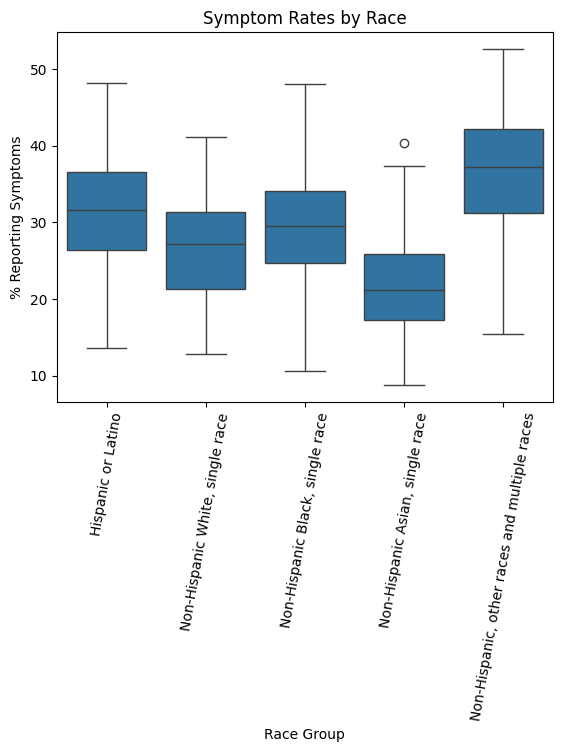

In [ ]:
plot = sns.boxplot(data=race_df, x='Subgroup', y='Value')
plot.set(
    xlabel='Race Group',
    ylabel='% Reporting Symptoms',
    title='Symptom Rates by Race'
)

# Make x-axis labels horizontal
plt.xticks(rotation=80)

plt.show()



In [ ]:
race_df['Value'].mean()
race_df['Value'].median()
race_df['Value'].min(), race_df['Value'].max()


(8.8, 52.6)

In [ ]:
# Mean symptom rate by race
race_df.groupby('Subgroup')['Value'].mean()

,Value
Subgroup,
Hispanic or Latino,31.654167
"Non-Hispanic Asian, single race",21.688426
"Non-Hispanic Black, single race",29.224074
"Non-Hispanic White, single race",26.877778
"Non-Hispanic, other races and multiple races",36.539352


In [ ]:
# Median symptom rate by race
race_df.groupby('Subgroup')['Value'].median()

,Value
Subgroup,
Hispanic or Latino,31.60
"Non-Hispanic Asian, single race",21.15
"Non-Hispanic Black, single race",29.60
"Non-Hispanic White, single race",27.20
"Non-Hispanic, other races and multiple races",37.20


In [ ]:
# Get min and max symptom rates for each race subgroup
race_min_max = race_df.groupby('Subgroup')['Value'].agg(['min', 'max'])

# Display the result
print(race_min_max)

                                               min   max
Subgroup                                                
Hispanic or Latino                            13.6  48.2
Non-Hispanic Asian, single race                8.8  40.3
Non-Hispanic Black, single race               10.7  48.0
Non-Hispanic White, single race               12.8  41.2
Non-Hispanic, other races and multiple races  15.5  52.6


### Multiple LM

In [ ]:
# get all unique group names
df['Group'].unique()

array(['national estimate', 'by age', 'by sex',
       'by race/hispanic ethnicity', 'by education', 'by state',
       'by disability status', 'by gender identity',
       'by sexual orientation'], dtype=object)

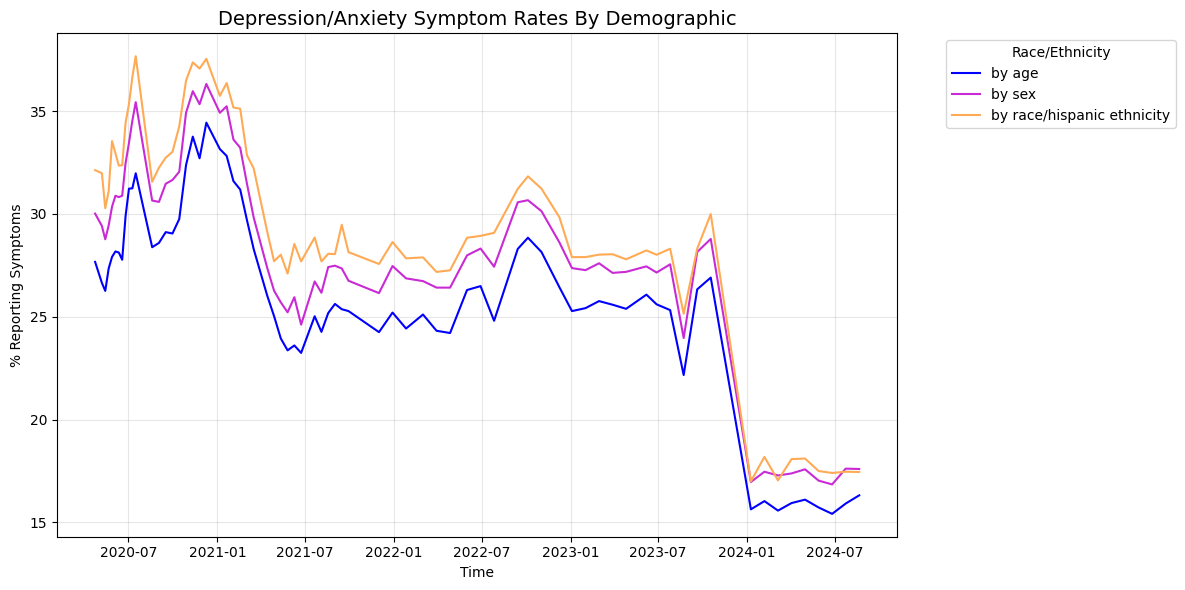

In [ ]:
# create final data frame with all three groups
final_df = df[df['Group'].isin([
    'by race/hispanic ethnicity',
    'by sex',
    'by age'
])]

# create the line plot
plt.figure(figsize = (12, 6))
sns.lineplot(
    data = final_df,
    x = 'Time Period Start Date',
    y = 'Value',
    hue = 'Group',
    errorbar = None,
    palette = 'gnuplot2'
)

# update layout
plt.grid(alpha = .3)
plt.title('Depression/Anxiety Symptom Rates By Demographic', fontsize=14)
plt.xlabel('Time')
plt.ylabel('% Reporting Symptoms')
plt.legend(title = 'Race/Ethnicity', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

In [ ]:
# one-hot encoding + make inputs
X = pd.get_dummies(final_df['Subgroup'], drop_first=True)
Y = final_df['Value']

# fit the model
mlm = LinearRegression()
mlm = mlm.fit(X, Y)

# print information; intercept = 18-29 age
print("Intercept:", mlm.intercept_)
print("Coefficients:", mlm.coef_)

Intercept: 41.307870370370274
Coefficients: [ -7.75       -11.61157407 -14.64444444 -20.67037037 -26.20462963
 -27.00787037 -10.52824074  -9.6537037  -16.25972222 -19.61944444
 -12.0837963  -14.43009259  -4.76851852]


In [ ]:
# use statsmodels library to get a more detailed output
import statsmodels.api as sm

# covert input to float (req for API)
X = X.astype(float)
Y = final_df['Value'].astype(float)

# add intercept
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     281.8
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        18:41:21   Log-Likelihood:                -10034.
No. Observations:                3024   AIC:                         2.010e+04
Df Residuals:                    3010   BIC:                         2.018e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### References

- https://www.cdc.gov/nchs/covid19/pulse/mental-health.htm (get data from this link)

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- https://seaborn.pydata.org/generated/seaborn.boxplot.html

- https://seaborn.pydata.org/generated/seaborn.lineplot.html

- https://seaborn.pydata.org/tutorial/regression.html

- https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

- https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html